In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhuvankumarapatri/brain-tumor")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/bhuvankumarapatri/brain-tumor


In [2]:
import os
import numpy as np
import torch
from torch import amp
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torchvision.models import swin_t, Swin_T_Weights
from torch.utils.data import DataLoader, random_split, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    matthews_corrcoef,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from scipy.stats import ttest_rel

from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

In [3]:
DATA_DIR = os.path.join(path, "Training")
TEST_DIR = os.path.join(path, "Testing")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# load WITHOUT transform
full_dataset = datasets.ImageFolder(DATA_DIR)
num_classes = len(full_dataset.classes)

labels = full_dataset.targets

# stratified split
train_idx, val_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

#  separate transforms
train_ds = Subset(
    datasets.ImageFolder(DATA_DIR, transform=train_transform),
    train_idx
)

val_ds = Subset(
    datasets.ImageFolder(DATA_DIR, transform=test_transform),
    val_idx
)

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_transform)

print("Classes:", full_dataset.classes)
print(len(train_ds), len(val_ds), len(test_ds))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
4569 1143 1311


In [5]:
base_swin = swin_t(weights=Swin_T_Weights.DEFAULT)

def build_swin(dropout, num_classes):
    import copy
    model = copy.deepcopy(base_swin)  # reuse weights

    in_features = model.head.in_features
    model.head = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 199MB/s] 


In [6]:
# Initialize once at the top
scaler = amp.GradScaler()

# Pass the scaler as an argument to make it flexible
def quick_train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with amp.autocast(device_type='cuda'):
            output = model(x)
            loss = criterion(output, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

def evaluate_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with amp.autocast(device_type='cuda'):
                output = model(x)
                pred = output.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    
    with torch.inference_mode():
        for x, y in loader:
            x = x.to(device)

            # AMP forward
            with amp.autocast(device_type='cuda'):
                out = model(x)

            # Softmax (stable + detached)
            probs = torch.softmax(out, dim=1).detach().cpu().numpy()
            y_score.extend(probs)

            preds = out.argmax(dim=1)
            y_pred.extend(preds.cpu().numpy())

            y_true.extend(y.cpu().numpy())

    final_acc = np.mean(np.array(y_true) == np.array(y_pred))

    return final_acc, np.array(y_pred), np.array(y_true), np.array(y_score)

In [7]:
def objective_swin(params):
    # ------------------------------
    # 1. Parameter Mapping
    # ------------------------------
    lr = 10 ** float(params[0])
    dropout = float(params[1])
    batch = int(round(params[2] / 8)) * 8   # GPU-friendly
    batch = max(16, min(64, batch))

    # ------------------------------
    # 2. DataLoader Setup
    # ------------------------------
    is_cuda = (device.type == "cuda")

    train_loader = DataLoader(
        train_ds,
        batch_size=batch,
        shuffle=True,
        num_workers=2,
        pin_memory=is_cuda
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch,
        shuffle=False,
        num_workers=2,
        pin_memory=is_cuda
    )

    # ------------------------------
    # 3. Model + Optimizer + Scaler
    # ------------------------------
    model = build_swin(dropout, num_classes)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    scaler = amp.GradScaler()   # 🔥 independent per candidate

    # ------------------------------
    # 4. 3-Epoch Fitness Training
    # ------------------------------
    for _ in range(3):
        quick_train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler
        )

    # ------------------------------
    # 5. Validation Accuracy
    # ------------------------------
    acc = evaluate_accuracy(model, val_loader)

    # ------------------------------
    # 6. Memory Cleanup
    # ------------------------------
    del model, optimizer, train_loader, val_loader, scaler
    import gc
    gc.collect()
    torch.cuda.empty_cache()

    return acc

In [8]:
class RandomSearchOptimizer:
    def __init__(self, obj_func, bounds, n_trials=130):
        """
        Args:
            obj_func: The objective function to minimize/maximize (objective_swin)
            bounds: List of tuples [(min, max), ...]
            n_trials: Total budget to match AO (Pop + Pop * Iter)
        """
        self.obj_func = obj_func
        self.bounds = bounds
        self.n_trials = n_trials

    def optimize(self):
        dim = len(self.bounds)
        lb = np.array([b[0] for b in self.bounds])
        ub = np.array([b[1] for b in self.bounds])

        best_params = None
        best_fit = -1.0

        print(f"🎲 Random Search Baseline Started | Budget: {self.n_trials} Trials")
        print(f"Settings: 3 Inner Epochs | AMP: Enabled | Architecture: Swin-T\n")

        # Progress bar matching AO style
        for i in tqdm(range(self.n_trials), desc="Random Searching"):
            # 1. Uniform Random Sampling (No Levy Flight, No Swarming)
            # candidate in the same space as AO
            candidate = np.random.uniform(lb, ub, size=dim)
            
            # 2. Evaluate using your objective_swin
            # This will trigger the 3-epoch training loop you've already defined
            try:
                fitness = self.obj_func(candidate)
            except Exception as e:
                print(f"⚠️ Trial {i+1} failed due to error: {e}")
                continue

            # 3. Track the Champion
            if fitness > best_fit:
                best_fit = fitness
                best_params = candidate.copy()
                
                # Visual feedback for your team update later
                print(f"\n🔥 NEW BEST FOUND (Trial {i+1})")
                print(f"   Accuracy: {best_fit:.4f}")
                print(f"   Params: LR=10^{best_params[0]:.2f}, Drop={best_params[1]:.3f}, Batch={int(best_params[2])}")

        print("\n🏆 RANDOM SEARCH BASELINE COMPLETE")
        return best_params, best_fit

# --- EXECUTION ---

# bounds to match exact AO settings
# (log10 LR, Dropout, Batch Size)
bounds = [
    (-5, -3),    # 10^-5 to 10^-3
    (0.1, 0.4),  # 0.1 to 0.4 dropout
    (16, 48)     # 16 to 48 batch size
]

# Initialize the optimizer with specific Swin objective
rs = RandomSearchOptimizer(objective_swin, bounds, n_trials=130)

# Run the search
best_params_rs, best_acc_rs = rs.optimize()


best_lr = 10 ** float(best_params_rs[0])
best_dropout = float(best_params_rs[1])

#  8-multiple rounding logic for consistency
best_batch_size = int(round(best_params_rs[2] / 8)) * 8
best_batch_size = max(16, min(64, best_batch_size))


print("\n" + "═"*50)
print("🎯 FINAL BASELINE RESULTS (RANDOM SEARCH)")
print("═"*50)
print(f"✅ BEST LEARNING RATE : {best_lr:.6f}")
print(f"✅ BEST DROPOUT       : {best_dropout:.3f}")
print(f"✅ BEST BATCH SIZE    : {best_batch_size}")
print(f"✅ BEST VAL ACCURACY  : {best_acc_rs:.4f}")
print("═"*50)

🎲 Random Search Baseline Started | Budget: 130 Trials
Settings: 3 Inner Epochs | AMP: Enabled | Architecture: Swin-T



Random Searching:   1%|          | 1/130 [01:44<3:44:41, 104.50s/it]


🔥 NEW BEST FOUND (Trial 1)
   Accuracy: 0.9764
   Params: LR=10^-4.45, Drop=0.332, Batch=18


Random Searching:   9%|▉         | 12/130 [18:54<3:09:10, 96.19s/it]


🔥 NEW BEST FOUND (Trial 12)
   Accuracy: 0.9843
   Params: LR=10^-4.64, Drop=0.123, Batch=18


...


🔥 NEW BEST FOUND (Trial 25)
   Accuracy: 0.9851
   Params: LR=10^-4.23, Drop=0.262, Batch=19


Random Searching:  38%|███▊      | 49/130 [1:17:51<2:10:11, 96.43s/it]


🔥 NEW BEST FOUND (Trial 49)
   Accuracy: 0.9860
   Params: LR=10^-3.92, Drop=0.267, Batch=38


Random Searching: 100%|██████████| 130/130 [3:27:33<00:00, 95.80s/it]  


🏆 RANDOM SEARCH BASELINE COMPLETE

══════════════════════════════════════════════════
🎯 FINAL BASELINE RESULTS (RANDOM SEARCH)
══════════════════════════════════════════════════
✅ BEST LEARNING RATE : 0.000119
✅ BEST DROPOUT       : 0.267
✅ BEST BATCH SIZE    : 40
✅ BEST VAL ACCURACY  : 0.9860
══════════════════════════════════════════════════


In [9]:
# --- 3. Initialize Model with Best Hyperparameters ---
model_cnx = build_swin(best_dropout, num_classes).to(device)

# --- 4. Define ALL Loaders with Optimized Batch Size ---
train_loader = DataLoader(train_ds, batch_size=best_batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=best_batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=best_batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- 5. Initialize Final Training Objects ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_cnx.parameters(), lr=best_lr)

In [10]:
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

best_val_acc = 0
patience = 5
counter = 0

scaler = amp.GradScaler()

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

for epoch in range(20):
    model_cnx.train()
    run_loss, correct, total = 0, 0, 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/20"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with amp.autocast(device_type='cuda'):
            out = model_cnx(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        run_loss += loss.item() * x.size(0)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_loss = run_loss / total
    train_acc = correct / total

    # ---------- VALIDATION ----------
    model_cnx.eval()
    v_loss, v_corr, v_tot = 0, 0, 0

    with torch.inference_mode():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            with amp.autocast(device_type='cuda'):
                out = model_cnx(x)
                loss = criterion(out, y)

            v_loss += loss.item() * x.size(0)
            pred = out.argmax(1)
            v_corr += (pred == y).sum().item()
            v_tot += y.size(0)

    val_loss = v_loss / v_tot
    val_acc = v_corr / v_tot

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1} | Train {train_acc:.4f} | Val {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model_cnx.state_dict(), "final_swin_rs.pth")
        print("✅ Best model saved")
    else:
        counter += 1

    if counter >= patience:
        print("🛑 Early stopping triggered")
        break

# Load best
model_cnx.load_state_dict(torch.load("final_swin_rs.pth", map_location=device))
model_cnx.eval()

Epoch 1/20: 100%|██████████| 115/115 [00:27<00:00,  4.17it/s]


Epoch 1 | Train 0.8575 | Val 0.9405
✅ Best model saved


Epoch 2/20: 100%|██████████| 115/115 [00:27<00:00,  4.13it/s]


Epoch 2 | Train 0.9466 | Val 0.9554
✅ Best model saved


Epoch 3/20: 100%|██████████| 115/115 [00:28<00:00,  4.08it/s]


...

Epoch 19/20: 100%|██████████| 115/115 [00:29<00:00,  3.93it/s]


Epoch 19 | Train 0.9985 | Val 0.9948
✅ Best model saved


Epoch 20/20: 100%|██████████| 115/115 [00:29<00:00,  3.89it/s]


Epoch 20 | Train 0.9989 | Val 0.9948


SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1): SwinTransformerBlock(
       

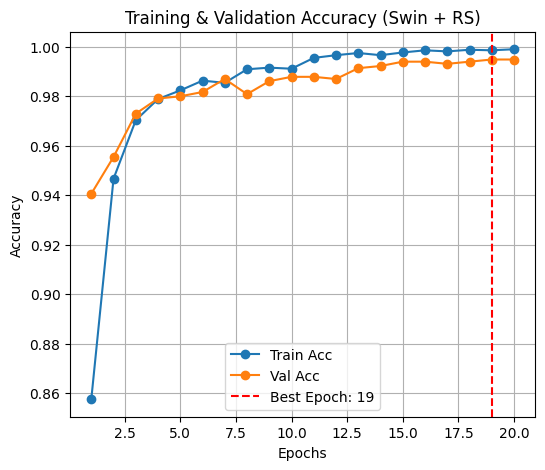

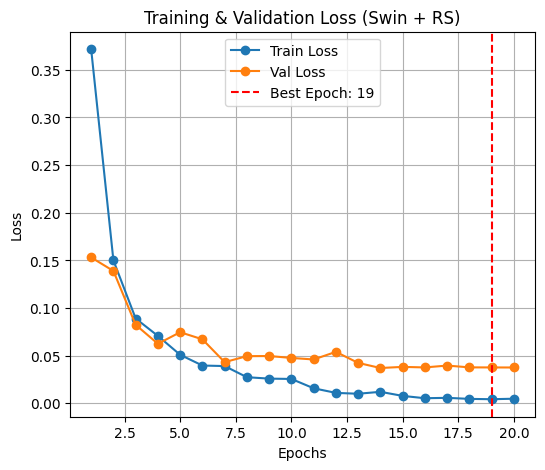

In [11]:
# Accuracy & Loss plots
epochs_range = range(1, len(history["train_acc"])+1)

# Determine best epoch
best_epoch = history["val_acc"].index(max(history["val_acc"])) + 1

# -----------------------
# Accuracy plot
# -----------------------
plt.figure(figsize=(6,5))
plt.plot(epochs_range, history["train_acc"], marker='o', label="Train Acc")
plt.plot(epochs_range, history["val_acc"], marker='o', label="Val Acc")
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f"Best Epoch: {best_epoch}")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy (Swin + RS)")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_plot.png", dpi=300)
plt.show()

# -----------------------
# Loss plot
# -----------------------
plt.figure(figsize=(6,5))
plt.plot(epochs_range, history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker='o', label="Val Loss")
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f"Best Epoch: {best_epoch}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Swin + RS)")
plt.legend()
plt.grid(True)
plt.savefig("loss_plot.png", dpi=300)
plt.show()


Swin + RS Test Accuracy: 0.9962

=== Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9966    0.9900    0.9933       300
  meningioma     0.9871    1.0000    0.9935       306
     notumor     1.0000    0.9975    0.9988       405
   pituitary     1.0000    0.9967    0.9983       300

    accuracy                         0.9962      1311
   macro avg     0.9959    0.9960    0.9960      1311
weighted avg     0.9962    0.9962    0.9962      1311



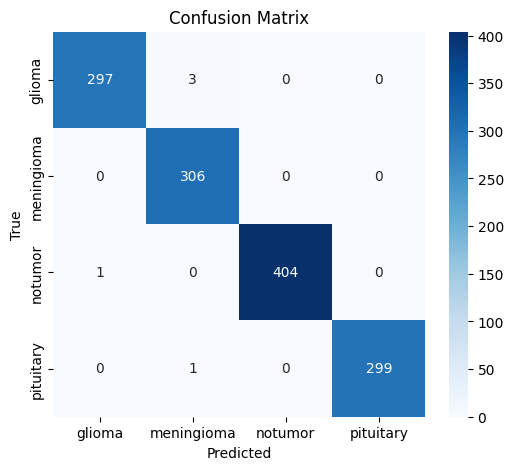


MCC: 0.9949
mAP: 0.9999


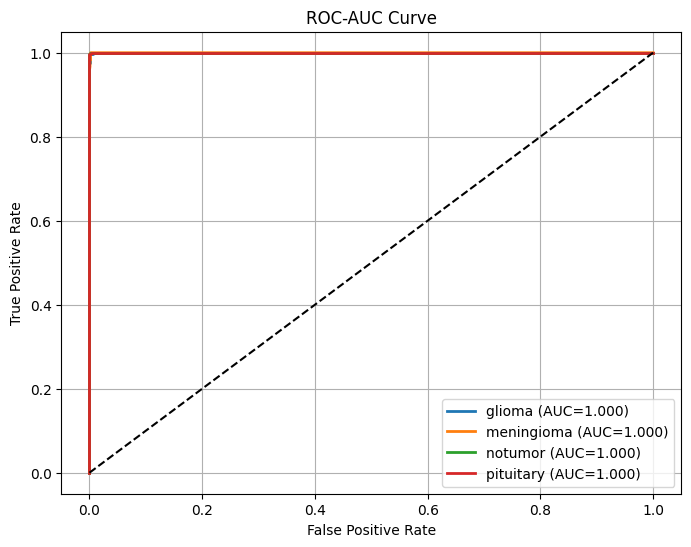

In [12]:
# ------------------------------
# Load Best Model (RS)
# ------------------------------
model_cnx.load_state_dict(torch.load("final_swin_rs.pth", map_location=device))
model_cnx.eval()

torch.cuda.empty_cache()

# ------------------------------
# Evaluate
# ------------------------------
acc, y_pred, y_true, y_score = evaluate(model_cnx, test_loader)

print(f"Swin + RS Test Accuracy: {acc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=full_dataset.classes,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mcc = matthews_corrcoef(y_true, y_pred)
print(f"\nMCC: {mcc:.4f}")

y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
mAP = average_precision_score(y_true_bin, y_score, average="macro")
print(f"mAP: {mAP:.4f}")

plt.figure(figsize=(8,6))
for i, cls in enumerate(full_dataset.classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Load the best checkpoint
best_model_state = torch.load("final_swin_rs.pth", map_location=device)

# Create the target directory if it doesn't exist
output_dir = "/kaggle/working"
os.makedirs(output_dir, exist_ok=True)

# Save it with a new filename
torch.save(best_model_state, os.path.join(output_dir, "final_swin_rs.pth"))
print("✅ Best model saved as final_swin_rs.pth")

✅ Best model saved as final_swin_rs.pth
